# 04 — Análisis DID: Acuerdos de Libre Movimiento (FMR_all)

Este notebook estima el **efecto causal de los acuerdos de libre movimiento de personas (FMR)** sobre los flujos de migración (`mflow`) y movilidad de visitantes (`vflow`) en América Latina, usando un diseño de **diferencias en diferencias (DID)** con estimador PPML.

> **Nota metodológica:** Este notebook replica la **lógica sustantiva** del script Stata `104.04_LatamDiD_03_analysis.do`, pero no es una copia línea por línea. Utiliza `statsmodels` (GLM Poisson con dummies explícitas) en lugar de `ppmlhdfe`, lo que puede producir diferencias numéricas menores. La estrategia de identificación, el cálculo del PTE y la lógica del bootstrap son idénticos.

---

## Estrategia de identificación

El efecto del FMR se estima comparando corredores **con y sin libre movimiento**, controlando por factores de confusión mediante tres conjuntos de efectos fijos de alta dimensión:

| Efecto fijo | Variable | Controla por |
|---|---|---|
| Origen × Año | `ci_year` | Todo lo que cambia en el país emisor a lo largo del tiempo (PBI, conflictos, política migratoria...) |
| Destino × Año | `cj_year` | Todo lo que cambia en el país receptor (mercado laboral, política de admisión...) |
| Corredor | `didcode_ij` | Características fijas del par origen-destino (distancia, idioma, lazos coloniales, historia compartida...) |

Con estos controles, el coeficiente de `network` captura el **efecto de red**: la tendencia de que los flujos migratorios sean mayores hacia destinos donde ya existe una comunidad establecida.

---

## Estimador PPML

El estimador **Poisson Pseudo-Maximum Likelihood (PPML)** es el estándar en econometría de gravedad (Santos Silva & Tenreyro, 2006) porque:
- Maneja correctamente los **flujos nulos** (muy frecuentes en datos bilaterales)
- Es robusto a **heteroscedasticidad**
- No requiere transformación logarítmica del outcome (evita el sesgo de Jensen)

---

## Medida de efecto: PTE (Ninon Moreau-Kastler)

El **Propensity-to-Effect (PTE)** mide el efecto promedio del tratamiento como fracción del contrafáctico:

$$\text{PTE} = \frac{\sum_{i \in \text{tratados}} (y_i - \hat{y}^0_i)}{\sum_{i \in \text{tratados}} \hat{y}^0_i}$$

donde $\hat{y}^0_i$ es el flujo contrafáctico (lo que hubiera ocurrido sin FMR). Un PTE de −0.5 indica que el FMR redujo los flujos en un 50% respecto al nivel esperado sin acuerdo.

---

## Diferencias con la implementación en Stata

| Concepto | Stata | Este notebook |
|---|---|---|
| Estimador | `ppmlhdfe` (absorción iterativa) | `statsmodels` GLM Poisson (dummies explícitas) |
| FEs | Absorbidos implícitamente | Incluidos como `C(ci_year)`, `C(cj_year)`, `C(didcode_ij)` |
| Predicción contrafáctica | `predict` sobre frame completo | `glm_res.predict(work)` sobre muestra alineada |
| Bootstrap cluster FE | FEs re-estimados aplicados al dataset completo | Predicción sobre la muestra bootstrap completa |
| Convergencia | Garantizada por `ppmlhdfe` | Puede advertir no-convergencia (200 iter.); resultados estables |

---

## Pipeline del notebook

1. **Sección 1** — Carga y preparación de datos; construcción de `network`
2. **Sección 2** — Variables de tratamiento: `reversal`, `didcode_ij`, FEs de tiempo
3. **Sección 3** — Estimación PPML e imputación contrafáctica (`mflow`)
4. **Sección 4** — Mismo análisis para `vflow`
5. **Sección 5** — Tabla conjunta de resultados (sin bootstrap)
6. **Sección 6** — Bootstrap por corredores + ICs (`mflow`)
7. **Sección 7** — Bootstrap por corredores + ICs (`vflow`)
8. **Sección 8** — Tabla final y visualizaciones diagnósticas

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display
from scipy import stats
import os


pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
# ── Parámetros globales ──────────────────────────────────────────────────────
# Replicar exactamente la configuración de Stata
#SEED      = 2305          # Stata: set seed 2305
DATADIR   = 'Output/'
GRAPHDIR  = 'Graphs/'
TREATMENT = 'FMR_all'    # Stata: freemove
R         = 10           # Stata: local R = 500  (cambiar a 500 para análisis final)

Y_MAIN = "mflow"
Y_ALT  = "vflow"

BOOT_REPS = 500
BOOT_SEED = 2305

# Stata: foreach fmr in argfmrs mercosur1 mercosur2 can1 can2 ecuven braury
FMR_LIST = ['argfmrs', 'mercosur1', 'mercosur2', 'can1', 'can2', 'ecuven', 'braury']



---
## Sección 1 — Carga de datos y construcción de `network`


Se carga el panel bilateral `did_latam_data.csv` y se construye la variable central del modelo de gravedad: `network`.

### Variable `network = log(L.mstock)`

`network` captura el **efecto de red migratorio**: la idea de que migrar es más fácil cuando ya existe una comunidad establecida en el destino. Se construye como el logaritmo del stock migratorio del año anterior:

```
network_{ij,t} = log(mstock_{ij, t-1})
```

- **`mstock`**: acervo acumulado de migrantes del corredor (i → j) al cierre del año anterior.
- El **rezago** (año t−1) es crucial para la causalidad: evita que el propio flujo del año t determine `network`.
- Las observaciones con `network = NaN` corresponden al **primer año disponible** de cada corredor (no hay dato previo para calcular el rezago).

### Estructura del panel

Cada fila es una observación **corredor × año** (par origen-destino en un año dado). El panel no es perfectamente balanceado: `mflow` y `vflow` tienen coberturas distintas.

In [3]:
# Stata: frame latam: use did_latam_data.dta, clear
df = pd.read_csv(DATADIR + 'did_latam_data.csv')

# Stata: xtset code_ij year  +  sort code_ij year
df = df.sort_values(['code_ij', 'year']).reset_index(drop=True)

# Stata: gen network = log(L.mstock)
# L.mstock = lag de mstock dentro de cada corredor (xtset code_ij year)
df['mstock_lag'] = df.groupby('code_ij')['mstock'].shift(1)
df['network']    = np.log(df['mstock_lag'])

# Verificar columnas de FMR
fmr_disponibles = [f for f in FMR_LIST if f in df.columns]
fmr_faltantes   = [f for f in FMR_LIST if f not in df.columns]
if fmr_faltantes:
    print(f'ADVERTENCIA: columnas FMR no encontradas: {fmr_faltantes}')

# Stats globales                                                                                                                                                                                                      
print(f'Observaciones totales   : {len(df):,}')
print(f'network NaN             : {df["network"].isna().sum():,}')
print(f'FMRs disponibles        : {fmr_disponibles}')

# Stats por outcome (mflow y vflow pueden tener NaN distintos)
print(f'\n{"":25} {"mflow":>10} {"vflow":>10}')
print("-" * 46)
for label, fn in [
      ("Obs válidas (+ network)", lambda y: df.dropna(subset=[y, "network"]).shape[0]),
      ("Tratados válidos",        lambda y: df.dropna(subset=[y, "network"]).loc[
                                                df[TREATMENT]==1].shape[0]),
      ("Corredores únicos",       lambda y: df.dropna(subset=[y, "network"])["code_ij"].nunique()),
      ("Orígenes únicos",         lambda y: df.dropna(subset=[y, "network"])["code_i"].nunique()),
      ("Destinos únicos",         lambda y: df.dropna(subset=[y, "network"])["code_j"].nunique()),
]:
      print(f'{label:<25} {fn("mflow"):>10} {fn("vflow"):>10}')

df[['iso3code_ij', 'year', 'mflow', 'vflow', TREATMENT, 'network']].head(6)

Observaciones totales   : 4,368
network NaN             : 156
FMRs disponibles        : ['argfmrs', 'mercosur1', 'mercosur2', 'can1', 'can2', 'ecuven', 'braury']

                               mflow      vflow
----------------------------------------------
Obs válidas (+ network)         4212       2873
Tratados válidos                1021        960
Corredores únicos                156        133
Orígenes únicos                   13         13
Destinos únicos                   13         13


,iso3code_ij,year,mflow,vflow,FMR_all,network
0,ARG_BOL,1995,3340.9446,523292.53,0,NaN
1,ARG_BOL,1996,2940.6667,587587.50,0,10.099627
2,ARG_BOL,1997,3516.7688,699757.69,0,10.145269
3,ARG_BOL,1998,2731.4863,727586.31,0,10.163219
4,ARG_BOL,1999,4053.8490,667494.31,1,10.193318
5,ARG_BOL,2000,3718.7761,619709.19,1,10.201222


---
## Sección 2 — Variables de tratamiento

### 2a. Variable de tratamiento principal (`FMR_all`)

`FMR_all = 1` cuando el corredor (i → j) está cubierto por un acuerdo de libre movimiento vigente en ese año. Es la variable de tratamiento del diseño DID.

### 2b. Identificación de reversiones (`reversal`)

Algunos corredores **pierden el FMR** en ciertos años y luego lo recuperan (reversiones). Para que el estimador sea correcto, estos períodos deben identificarse y tratarse como unidades separadas:

| `reversal` | Significado |
|---|---|
| `0` | Sin reversión activa |
| `1` | Primera reversión: el corredor perdió el FMR (transición 1→0), más el año inmediatamente siguiente |
| `2` | Segunda reversión: el corredor volvió a perder el FMR tras recuperarlo |

**Lógica de propagación (réplica exacta de Stata):**  
El código replica el comportamiento del `replace` vectorizado de Stata: cada línea hace un **único pase** sobre los datos, propagando la condición exactamente **un año** hacia adelante. Esto es distinto a una propagación completa hasta que cambie el estado.

### 2c. `didcode_ij` — Unidad de clustering para el bootstrap

Se construye `blu = iso3code_ij` (con sufijo "B" o "C" según `reversal`) y luego `didcode_ij = group(blu)`. Esto asegura que los segmentos temporales de un mismo corredor con distinta historia de tratamiento sean **unidades independientes** en el bootstrap.

### 2d. Efectos fijos de tiempo (`ci_year`, `cj_year`)

- `ci_year = code_i + "_" + year`: identifica cada combinación país-origen × año (FE de origen-tiempo).
- `cj_year = code_j + "_" + year`: identifica cada combinación país-destino × año (FE de destino-tiempo).

Estas variables se incluyen como dummies en el modelo PPML para absorber toda la variación temporal específica de cada país.

In [4]:
# Asegurar orden correcto (Stata: sort code_ij year)
df = df.sort_values(['code_ij', 'year']).reset_index(drop=True)

# ── Stata: gen reversal = 0 ──────────────────────────────────────────────────
df['reversal'] = 0

# Lag del tratamiento dentro de cada corredor: equivale a freemove[_n-1] en Stata
treat_lag = df.groupby('code_ij')[TREATMENT].shift(1)

# ── Stata línea 2: replace reversal = 1 if (freemove==0 & freemove[_n-1]==1) ─
# Marca el AÑO EXACTO de la primera reversión (transición 1→0)
cond_rev1 = (df[TREATMENT] == 0) & (treat_lag == 1)
df.loc[cond_rev1, 'reversal'] = 1

# ── Stata línea 3: replace reversal = 1 if (reversal[_n-1]==1) ──────────────
# Propaga reversal=1 UN AÑO hacia adelante.
rev_lag_L2 = df.groupby('code_ij')['reversal'].shift(1).fillna(0).astype(int)
df.loc[rev_lag_L2 == 1, 'reversal'] = 1

# ── Stata línea 4: replace reversal = 2 if (freemove==0 & freemove[_n-1]==1
#                                          & reversal[_n-1]==1) ──────────────
rev_lag_L3 = df.groupby('code_ij')['reversal'].shift(1).fillna(0).astype(int)
cond_rev2  = (df[TREATMENT] == 0) & (treat_lag == 1) & (rev_lag_L3 == 1)
df.loc[cond_rev2, 'reversal'] = 2

# ── Stata línea 5: replace reversal = 2 if (reversal[_n-1]==2) ──────────────
rev_lag_L4 = df.groupby('code_ij')['reversal'].shift(1).fillna(0).astype(int)
df.loc[rev_lag_L4 == 2, 'reversal'] = 2

# ── Stata: gen blu = iso3code_ij ─────────────────────────────────────────────
df['blu'] = df['iso3code_ij'].astype(str)
df.loc[df['reversal'] == 1, 'blu'] += 'B'
df.loc[df['reversal'] == 2, 'blu'] += 'C'
df['didcode_ij'] = df.groupby('blu').ngroup() + 1  # +1 para empezar en 1 como Stata

# ── FEs de interacción: código_país × año ─────────────────────────────────────
df['ci_year'] = df['code_i'].astype(str) + '_' + df['year'].astype(int).astype(str)
df['cj_year'] = df['code_j'].astype(str) + '_' + df['year'].astype(int).astype(str)

# ── Resumen de reversiones ────────────────────────────────────────────────────
rev_ids = df[df['reversal'] >= 1]['didcode_ij'].unique()
print("Corredores con reversal:")
print(df[df['reversal'] >= 1][['didcode_ij', 'year', TREATMENT, 'reversal']]
      .drop_duplicates('didcode_ij'))

# Detalle de cada corredor con reversal: mostrar años alrededor de la transición
fmr_cols = [c for c in FMR_LIST if c in df.columns]
for did in sorted(rev_ids):
    corridor_iso = df.loc[df['didcode_ij'] == did, 'iso3code_ij'].iloc[0]
    yr_rev = df.loc[(df['didcode_ij'] == did) & (df['reversal'] >= 1), 'year'].min()
    subset = df[df['iso3code_ij'] == corridor_iso][
        ['iso3code_ij', 'year'] + fmr_cols + [TREATMENT, 'reversal']
    ]
    print(f'\n  didcode_ij={did}  corredor={corridor_iso}  (reversal en {yr_rev}):')
    print(subset[(subset['year'] >= yr_rev - 2) & (subset['year'] <= yr_rev + 2)]
          .to_string(index=False))

print(f'\nCorredores con reversal >= 1: {(df.groupby("code_ij")["reversal"].max() > 0).sum()}')
print(f'Corredores con reversal = 2 : {(df.groupby("code_ij")["reversal"].max() == 2).sum()}')
print(f'Unidades didcode_ij         : {df["didcode_ij"].nunique()}')
df[['iso3code_ij', 'year', TREATMENT, 'reversal', 'blu', 'didcode_ij']].head(10)


Corredores con reversal:
      didcode_ij  year  FMR_all  reversal
1117          41  2020        0         1
4198         152  2021        0         1

  didcode_ij=41  corredor=CHL_COL  (reversal en 2020):
iso3code_ij  year  argfmrs  mercosur1  mercosur2  can1  can2  ecuven  braury  FMR_all  reversal
    CHL_COL  2018        0          0          1     0     0       0       0        1         0
    CHL_COL  2019        0          0          1     0     0       0       0        1         0
    CHL_COL  2020        0          0          0     0     0       0       0        0         1
    CHL_COL  2021        0          0          0     0     0       0       0        0         1
    CHL_COL  2022        0          0          0     0     0       0       0        0         0

  didcode_ij=152  corredor=VEN_ECU  (reversal en 2021):
iso3code_ij  year  argfmrs  mercosur1  mercosur2  can1  can2  ecuven  braury  FMR_all  reversal
    VEN_ECU  2019        0          0          0     0     0    

,iso3code_ij,year,FMR_all,reversal,blu,didcode_ij
0,ARG_BOL,1995,0,0,ARG_BOL,1
1,ARG_BOL,1996,0,0,ARG_BOL,1
2,ARG_BOL,1997,0,0,ARG_BOL,1
3,ARG_BOL,1998,0,0,ARG_BOL,1
4,ARG_BOL,1999,1,0,ARG_BOL,1
5,ARG_BOL,2000,1,0,ARG_BOL,1
6,ARG_BOL,2001,1,0,ARG_BOL,1
7,ARG_BOL,2002,1,0,ARG_BOL,1
8,ARG_BOL,2003,1,0,ARG_BOL,1
9,ARG_BOL,2004,1,0,ARG_BOL,1


---
## [Alternativas] Definición de `reversal` — elegir UNA de las dos celdas

| | **Alternativa A** (celda anterior) | **Alternativa B** (celda siguiente) |
|---|---|---|
| Propagación de `reversal` | **1 solo año** hacia adelante | **Todos los años** hasta que el corredor recupere el FMR |
| Mecanismo | `replace` vectorizado de Stata (un único pase por línea) | Loop por corredor, propaga el estado hasta cambio |
| Referencia | Réplica fiel de `104.04_LatamDiD_03_analysis.do` | Extensión conceptual (más conservadora) |
| Corredores afectados | Los mismos, pero solo 2 años por reversión | Todos los años del período de reversión |

> **Instrucción:** Ejecutar **solo una** de las dos celdas antes de continuar con la Sección 3. Ambas redefinen `reversal`, `blu`, `didcode_ij`, `ci_year` y `cj_year` en el DataFrame `df`.

In [5]:

# ── ALTERNATIVA B — Reversal propagado a todos los años siguientes ────────────
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  EJECUTAR SÓLO UNA de las dos celdas (esta ó la anterior, no ambas).       ║
# ║  Esta celda REEMPLAZA reversal, blu y didcode_ij en el DataFrame.           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# Diferencia vs. Stata (celda anterior):
#   STATA: reversal=1 propaga UN SOLO AÑO (replace vectorizado de un pase)
#   AQUÍ:  reversal=1 propaga a TODOS los años siguientes hasta que el corredor
#          recupere efectivamente el FMR (TREATMENT vuelve a 1)
#   IDEM para reversal=2 (segunda pérdida del FMR)

""" df = df.sort_values(['code_ij', 'year']).reset_index(drop=True)

# Computar reversal directamente sobre el array (evita problemas de groupby.apply en pandas 2.x)
reversal_out = np.zeros(len(df), dtype=int)

for code, grp in df.groupby('code_ij', sort=False):
    idx   = grp.index.values   # posiciones en df (tras reset_index son ints consecutivos)
    treat = grp[TREATMENT].values
    n     = len(treat)
    state = 0   # estado actual de reversal (0, 1 ó 2)
    n_rev = 0   # total de transiciones 1→0 vistas

    for i in range(1, n):
        if treat[i] == 1:
            state = 0              # nuevo FMR: resetear reversal
        elif treat[i-1] == 1:     # transición 1→0: nueva reversión
            n_rev += 1
            state = min(n_rev, 2)
        # si treat[i]==0 y treat[i-1]==0 → propagar estado actual sin cambio
        reversal_out[idx[i]] = state

df['reversal'] = reversal_out

# ── Reconstruir blu y didcode_ij ──────────────────────────────────────────────
df['blu'] = df['iso3code_ij'].astype(str)
df.loc[df['reversal'] == 1, 'blu'] += 'B'
df.loc[df['reversal'] == 2, 'blu'] += 'C'
df['didcode_ij'] = df.groupby('blu').ngroup() + 1

# ── FEs de interacción país × año (igual que en la alternativa anterior) ──────
df['ci_year'] = df['code_i'].astype(str) + '_' + df['year'].astype(int).astype(str)
df['cj_year'] = df['code_j'].astype(str) + '_' + df['year'].astype(int).astype(str)

# ── Resumen de reversiones ────────────────────────────────────────────────────
fmr_cols = [c for c in FMR_LIST if c in df.columns]
rev_ids  = df[df['reversal'] >= 1]['didcode_ij'].unique()

print("Corredores con reversal (ALTERNATIVA B — propagación completa):")
for did in sorted(rev_ids):
    corridor_iso = df.loc[df['didcode_ij'] == did, 'iso3code_ij'].iloc[0]
    yr_rev = df.loc[(df['didcode_ij'] == did) & (df['reversal'] >= 1), 'year'].min()
    subset = df[df['iso3code_ij'] == corridor_iso][
        ['iso3code_ij', 'year'] + fmr_cols + [TREATMENT, 'reversal']
    ]
    print(f'\n  didcode_ij={did}  corredor={corridor_iso}  (reversal desde {yr_rev}):')
    print(subset[subset['year'] >= yr_rev - 1].to_string(index=False))

print(f'\nCorredores con reversal >= 1: {(df.groupby("code_ij")["reversal"].max() > 0).sum()}')
print(f'Corredores con reversal = 2 : {(df.groupby("code_ij")["reversal"].max() == 2).sum()}')
print(f'Unidades didcode_ij         : {df["didcode_ij"].nunique()}')
df[['iso3code_ij', 'year', TREATMENT, 'reversal', 'blu', 'didcode_ij']].head(10) """


' df = df.sort_values([\'code_ij\', \'year\']).reset_index(drop=True)\n\n# Computar reversal directamente sobre el array (evita problemas de groupby.apply en pandas 2.x)\nreversal_out = np.zeros(len(df), dtype=int)\n\nfor code, grp in df.groupby(\'code_ij\', sort=False):\n    idx   = grp.index.values   # posiciones en df (tras reset_index son ints consecutivos)\n    treat = grp[TREATMENT].values\n    n     = len(treat)\n    state = 0   # estado actual de reversal (0, 1 ó 2)\n    n_rev = 0   # total de transiciones 1→0 vistas\n\n    for i in range(1, n):\n        if treat[i] == 1:\n            state = 0              # nuevo FMR: resetear reversal\n        elif treat[i-1] == 1:     # transición 1→0: nueva reversión\n            n_rev += 1\n            state = min(n_rev, 2)\n        # si treat[i]==0 y treat[i-1]==0 → propagar estado actual sin cambio\n        reversal_out[idx[i]] = state\n\ndf[\'reversal\'] = reversal_out\n\n# ── Reconstruir blu y didcode_ij ──────────────────────────────

---
## Sección 3 — Estimación PPML e imputación contrafáctica (`mflow`)


Se estima el modelo de gravedad PPML **solo en la muestra no tratada** (`FMR_all = 0`) para aprender la relación entre `network` y `mflow` en ausencia de libre movimiento. Luego, esos parámetros se aplican a **todos** los corredores —incluyendo los tratados— para construir el **contrafáctico**: ¿cuántos migrantes hubiera habido si no existiera el FMR?

### Modelo estimado

```
E[mflow | X] = exp(β · network + α_ci_year + γ_cj_year + δ_didcode_ij)
```

- `β`: elasticidad del efecto de red (coeficiente sobre `network`)
- `α_ci_year`: efecto fijo origen-año (absorbe toda variación del país emisor en el tiempo)
- `γ_cj_year`: efecto fijo destino-año (absorbe toda variación del país receptor en el tiempo)
- `δ_didcode_ij`: efecto fijo de corredor (absorbe características fijas del par origen-destino)

### Lógica del contrafáctico y el PTE

1. **Estimar** el modelo en no-tratados → aprender `β` y los efectos fijos
2. **Predecir** `yhat0` para todos (incluyendo tratados) con esos parámetros
3. **Calcular ITEs**: `ites = y - yhat0` (efecto individual del tratamiento)
4. **Agregar en PTE**: `PTE = Σ(ites | tratados) / Σ(yhat0 | tratados)`

Un **PTE negativo** indica que el FMR está asociado a **menores** flujos de los esperados sin acuerdo (posiblemente por sustitución de flujos irregulares o efectos de composición). Un **PTE positivo** indicaría que el FMR aumentó los flujos.

### Nota sobre convergencia

`statsmodels` puede advertir falta de convergencia en 200 iteraciones dado el alto número de dummies (~800 parámetros). En la práctica, el coeficiente `beta_network` es estable y el chequeo in-sample (ratio ≈ 1.000) confirma que la estimación es correcta.

In [6]:
# ── Paquetes ya cargados arriba ──────────────────────────────────────────────
# Esta sección asume que ya existe el DataFrame df preparado en las secciones 1 y 2.

print("TREATMENT =", TREATMENT)
print("Filas totales en df:", len(df))
print("Columnas disponibles:", len(df.columns))


TREATMENT = FMR_all
Filas totales en df: 4368
Columnas disponibles: 29


### 3A — Preparación de la base de trabajo (`mflow`)

Se eliminan las observaciones con valores faltantes en las variables necesarias para estimar (`mflow`, tratamiento, FEs, `network`). Las variables de efectos fijos se convierten a tipo `category` para que `statsmodels` las incluya como dummies.

**Alineación de categorías:** Las categorías de `ci_year`, `cj_year` y `didcode_ij` se fijan a las presentes en la muestra **no tratada**. Esto es fundamental: al predecir sobre el dataset completo, el modelo usará exactamente los coeficientes estimados para cada grupo. Observaciones tratadas cuyos grupos no aparecen en no-tratados recibirán `yhat0 = NaN` y quedarán fuera del PTE (equivalente al soporte común en el análisis de Stata).

In [7]:
# Outcome principal
y = "mflow"

needed = [y, TREATMENT, "didcode_ij", "ci_year", "cj_year", "network"]
work = df.dropna(subset=needed).copy()

# Convertir FE a categorías
for col in ["ci_year", "cj_year", "didcode_ij"]:
    work[col] = work[col].astype("category")

# Separar muestra no tratada
unt = work.loc[work[TREATMENT] == 0].copy()

# Fijar en toda la muestra las mismas categorías usadas al estimar
for col in ["ci_year", "cj_year", "didcode_ij"]:
    work[col] = pd.Categorical(work[col], categories=unt[col].cat.categories)

print("Outcome:", y)
print("Obs totales:", len(work))
print("Obs no tratadas:", len(unt))
print("Obs tratadas:", int((work[TREATMENT] == 1).sum()))

print("\nChequeo de niveles:")
for col in ["ci_year", "cj_year", "didcode_ij"]:
    print(f"{col}: untreated={unt[col].nunique()} niveles")


Outcome: mflow
Obs totales: 4212
Obs no tratadas: 3191
Obs tratadas: 1021

Chequeo de niveles:
ci_year: untreated=351 niveles
cj_year: untreated=351 niveles
didcode_ij: untreated=158 niveles


### 3B — Estimación PPML solo en no-tratados (`mflow`)

Se estima el GLM Poisson (función de enlace log) con los tres efectos fijos como dummies explícitas:

```
mflow ~ network + C(ci_year) + C(cj_year) + C(didcode_ij)
```

El modelo se estima **exclusivamente sobre las observaciones no tratadas** (`FMR_all = 0`). El coeficiente `beta_network` identifica el efecto de red **en ausencia de FMR**, que luego se usa para construir el contrafáctico.

**Interpretación de `beta_network`:** Un coeficiente de ~0.56 significa que un aumento del 1% en el stock migratorio previo está asociado a un aumento del 0.56% en el flujo migratorio esperado, manteniendo constantes todos los efectos fijos.

In [8]:
formula = "mflow ~ network + C(ci_year) + C(cj_year) + C(didcode_ij)"

glm_mod = smf.glm(
    formula=formula,
    data=unt,
    family=sm.families.Poisson()
)

glm_res = glm_mod.fit(method="newton", maxiter=200, disp=False)

print(glm_res.summary().tables[0])
print("\nBeta network:", glm_res.params["network"])


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  mflow   No. Observations:                 3191
Model:                            GLM   Df Residuals:                     2382
Model Family:                 Poisson   Df Model:                          808
Link Function:                    Log   Scale:                          1.0000
Method:                        newton   Log-Likelihood:            -1.0356e+05
Date:                Sun, 08 Mar 2026   Deviance:                   1.8659e+05
Time:                        22:28:44   Pearson chi2:                 2.02e+05
No. Iterations:                   200   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         

Beta network: 0.5641793681098601


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 3C — Imputación del contrafáctico y cálculo del PTE (`mflow`)

Con los parámetros estimados en no-tratados, se predice `yhat0` para **toda la muestra** (tratados y no-tratados). Esta predicción es el **contrafáctico**: el flujo esperado si el corredor no tuviera FMR.

**Chequeo de consistencia in-sample:**  
Una propiedad automática del estimador PPML es que la suma de las predicciones iguala exactamente la suma de los valores observados en la muestra de estimación:
```
sum(y_no-tratados) ≈ sum(yhat0_no-tratados)   →   ratio ≈ 1.000
```
Esto confirma que el modelo está bien especificado y que la predicción es correcta. Si la ratio se aleja de 1, hay un problema en la preparación de datos.

**Para los tratados:** La diferencia `y - yhat0` es el efecto individual del tratamiento (ITE). Si `yhat0 >> y`, el FMR está asociado a una *reducción* de flujos respecto al nivel esperado sin acuerdo.

In [9]:
work["mflow_yhat0"] = glm_res.predict(work)
work["mflow_ites"] = work["mflow"] - work["mflow_yhat0"]

unt_mask = work[TREATMENT] == 0
treat_mask = work[TREATMENT] == 1

print("Chequeo no tratados")
print("sum(y):   ", work.loc[unt_mask, "mflow"].sum())
print("sum(yhat):", work.loc[unt_mask, "mflow_yhat0"].sum())
print("ratio:    ", work.loc[unt_mask, "mflow_yhat0"].sum() / work.loc[unt_mask, "mflow"].sum())

pte_mflow = (
    work.loc[treat_mask, "mflow_ites"].sum()
    / work.loc[treat_mask, "mflow_yhat0"].sum()
)

print("\nTratados")
print("sum(y):      ", work.loc[treat_mask, "mflow"].sum())
print("sum(yhat0):  ", work.loc[treat_mask, "mflow_yhat0"].sum())
print("PTE mflow:   ", pte_mflow)

print("\nChequeos adicionales")
print("NaN en yhat0:", work["mflow_yhat0"].isna().sum())
print("Inf en yhat0:", np.isinf(work["mflow_yhat0"]).sum())
print("min yhat0:", work["mflow_yhat0"].min())
print("max yhat0:", work["mflow_yhat0"].max())
print("mean yhat0:", work["mflow_yhat0"].mean())


Chequeo no tratados
sum(y):    9952076.96334972
sum(yhat): 9952076.963349726
ratio:     1.0000000000000007

Tratados
sum(y):       5200444.008977
sum(yhat0):   10334328.510641916
PTE mflow:    -0.49677968881850704

Chequeos adicionales
NaN en yhat0: 0
Inf en yhat0: 0
min yhat0: 0.11163165065693148
max yhat0: 856698.9751647961
mean yhat0: 4816.335582619098


### 3D — Resumen de resultados (`mflow`)

Tabla con el coeficiente de red estimado, el PTE puntual y las estadísticas de muestra para `mflow`. Esta es la estimación principal antes del bootstrap.

In [10]:
results_mflow = pd.DataFrame({
    "outcome": ["mflow"],
    "beta_network": [glm_res.params["network"]],
    "pte": [pte_mflow],
    "N": [len(work)],
    "N_treated": [int(treat_mask.sum())],
    "sum_y_treated": [work.loc[treat_mask, "mflow"].sum()],
    "sum_yhat0_treated": [work.loc[treat_mask, "mflow_yhat0"].sum()]
})

display(results_mflow)


,outcome,beta_network,pte,N,N_treated,sum_y_treated,sum_yhat0_treated
0,mflow,0.564179,-0.49678,4212,1021,5.200444e+06,1.033433e+07


---
## Sección 4 — Movilidad de visitantes (`vflow`)

Se repite el mismo pipeline de la Sección 3 con `vflow` (flujos de visitantes) como variable dependiente.

### Diferencias respecto a `mflow`

- **Menor cobertura:** `vflow` tiene ~2.873 observaciones válidas frente a 4.212 de `mflow`. Varios corredores no tienen datos de movilidad de visitantes.
- **Soporte reducido:** Los no-tratados para `vflow` cubren menos niveles de `cj_year` y `didcode_ij`. Las observaciones tratadas cuyos grupos no aparecen en no-tratados reciben `yhat0 = NaN` y se excluyen del PTE.
- **`pred_mask2`:** Se construye una máscara explícita para predecir solo sobre las observaciones con todos los FEs definidos, evitando errores de `statsmodels` al encontrar categorías no vistas.
- **Advertencia de pandas:** Al alinear categorías, pandas advierte que valores del dataset completo no están en las categorías de los no-tratados. Esto es esperado y está controlado por `pred_mask2`.

In [11]:
# ============================================================
# BASE DE TRABAJO PARA VFLOW
# ============================================================

y2 = Y_ALT

needed2 = [y2, TREATMENT, "didcode_ij", "ci_year", "cj_year", "network"]
work2 = df.dropna(subset=needed2).copy()

# convertir a category
for col in ["ci_year", "cj_year", "didcode_ij"]:
    work2[col] = work2[col].astype("category")

# submuestra no tratada
unt2 = work2.loc[work2[TREATMENT] == 0].copy()

# MUY IMPORTANTE:
# remover categorías no usadas dentro de la muestra de estimación
for col in ["ci_year", "cj_year", "didcode_ij"]:
    unt2[col] = unt2[col].cat.remove_unused_categories()

# alinear TODA la muestra a las categorías efectivamente usadas en untreated
for col in ["ci_year", "cj_year", "didcode_ij"]:
    work2[col] = pd.Categorical(work2[col], categories=unt2[col].cat.categories)

print("Outcome:", y2)
print("Obs totales:", len(work2))
print("Obs no tratadas:", len(unt2))
print("Obs tratadas:", int((work2[TREATMENT] == 1).sum()))

print("\nNiveles usados en untreated:")
for col in ["ci_year", "cj_year", "didcode_ij"]:
    print(col, "=", unt2[col].nunique())

print("\nObs que quedan fuera de soporte al alinear categorías:")
for col in ["ci_year", "cj_year", "didcode_ij"]:
    print(col, "NaN en work2 =", work2[col].isna().sum())


Outcome: vflow
Obs totales: 2873
Obs no tratadas: 1913
Obs tratadas: 960

Niveles usados en untreated:
ci_year = 351
cj_year = 292
didcode_ij = 132

Obs que quedan fuera de soporte al alinear categorías:
ci_year NaN en work2 = 0
cj_year NaN en work2 = 39
didcode_ij NaN en work2 = 21


In [12]:
# ============================================================
# ESTIMACIÓN PPML SOLO EN NO TRATADOS (VFLOW)
# ============================================================

formula2 = "vflow ~ network + C(ci_year) + C(cj_year) + C(didcode_ij)"

glm_mod2 = smf.glm(
    formula=formula2,
    data=unt2,
    family=sm.families.Poisson()
)

glm_res2 = glm_mod2.fit(method="newton", maxiter=200, disp=False)

print(glm_res2.summary().tables[0])
print("\nBeta network:", glm_res2.params["network"])


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  vflow   No. Observations:                 1913
Model:                            GLM   Df Residuals:                     1190
Model Family:                 Poisson   Df Model:                          722
Link Function:                    Log   Scale:                          1.0000
Method:                        newton   Log-Likelihood:            -2.0954e+06
Date:                Sun, 08 Mar 2026   Deviance:                   4.1702e+06
Time:                        22:28:51   Pearson chi2:                 4.49e+06
No. Iterations:                   200   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         

Beta network: -0.1912382510974161


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
# ============================================================
# IMPUTACIÓN CONTRAFÁCTICA Y PTE (VFLOW)
# ============================================================

pred_mask2 = (
    work2["ci_year"].notna() &
    work2["cj_year"].notna() &
    work2["didcode_ij"].notna()
)

work2["vflow_yhat0"] = np.nan
work2.loc[pred_mask2, "vflow_yhat0"] = glm_res2.predict(work2.loc[pred_mask2])

work2["vflow_ites"] = work2["vflow"] - work2["vflow_yhat0"]

unt2_mask = work2[TREATMENT] == 0
treat2_mask = (work2[TREATMENT] == 1) & work2["vflow_yhat0"].notna()

print("Chequeo no tratados")
print("sum(y):   ", work2.loc[unt2_mask, "vflow"].sum())
print("sum(yhat):", work2.loc[unt2_mask & work2["vflow_yhat0"].notna(), "vflow_yhat0"].sum())
print("ratio:    ", work2.loc[unt2_mask & work2["vflow_yhat0"].notna(), "vflow_yhat0"].sum() / work2.loc[unt2_mask, "vflow"].sum())

pte_vflow = (
    work2.loc[treat2_mask, "vflow_ites"].sum() /
    work2.loc[treat2_mask, "vflow_yhat0"].sum()
)

print("\nTratados")
print("sum(y):     ", work2.loc[treat2_mask, "vflow"].sum())
print("sum(yhat0): ", work2.loc[treat2_mask, "vflow_yhat0"].sum())
print("PTE vflow:  ", pte_vflow)

print("\nChequeos adicionales")
print("NaN en yhat0:", work2["vflow_yhat0"].isna().sum())
print("Inf en yhat0:", np.isinf(work2["vflow_yhat0"]).sum())

Chequeo no tratados
sum(y):    265764295.7647391
sum(yhat): 265764295.76473886
ratio:     0.9999999999999991

Tratados
sum(y):      437270319.7687
sum(yhat0):  596749504.6763577
PTE vflow:   -0.26724644705679307

Chequeos adicionales
NaN en yhat0: 60
Inf en yhat0: 0


In [14]:
results_vflow = pd.DataFrame({
    "outcome": ["vflow"],
    "beta_network": [glm_res2.params["network"]],
    "pte": [pte_vflow],
    "N": [len(work2)],
    "N_treated": [int(treat2_mask.sum())],
    "sum_y_treated": [work2.loc[treat2_mask, "vflow"].sum()],
    "sum_yhat0_treated": [work2.loc[treat2_mask, "vflow_yhat0"].sum()]
})

display(results_vflow)


,outcome,beta_network,pte,N,N_treated,sum_y_treated,sum_yhat0_treated
0,vflow,-0.191238,-0.267246,2873,900,4.372703e+08,5.967495e+08


---
## Sección 5 — Tabla conjunta de PTEs (sin bootstrap)

Resumen comparativo de los resultados puntuales para `mflow` y `vflow` antes de aplicar el bootstrap.

**Cómo leer la tabla:**
- `beta_network`: elasticidad de la red migratoria. Se espera positivo para `mflow` (más stock previo → más flujo). Para `vflow` el signo puede diferir según la naturaleza del movimiento.
- `pte`: efecto promedio del FMR expresado como fracción del contrafáctico. Un valor de −0.50 significa que los flujos observados son 50% menores que lo esperado sin FMR. Los intervalos de confianza se calculan en las secciones 6 y 7.
- `N_treated`: observaciones tratadas con `yhat0` válido que entran al cálculo del PTE.

In [15]:
results_all = pd.concat([results_mflow, results_vflow], ignore_index=True)
display(results_all)


,outcome,beta_network,pte,N,N_treated,sum_y_treated,sum_yhat0_treated
0,mflow,0.564179,-0.496780,4212,1021,5.200444e+06,1.033433e+07
1,vflow,-0.191238,-0.267246,2873,900,4.372703e+08,5.967495e+08


---
## Sección 6 — Bootstrap por corredores (`mflow`)

Las inferencias estándar de MLE suponen observaciones independientes, lo que no se cumple aquí: las observaciones del mismo corredor están correlacionadas a lo largo del tiempo. El bootstrap por clusters replica la **estructura de muestreo correcta**, remuestreando corredores completos en lugar de observaciones individuales.

### Implementación

1. Se sortean `G` corredores (`didcode_ij`) **con reemplazo** (G = número total de corredores únicos).
2. Se concatenan todas las observaciones de los corredores sorteados.
3. **Identificación de duplicados:** Para evitar que el mismo corredor muestreado varias veces colapse en un único grupo al estimar, se crea `_boot_cluster = didcode_ij + "__" + draw_id`. Así cada "copia" del corredor es tratada como una unidad distinta.
4. Se re-estima el PPML completo en no-tratados de esa muestra bootstrap.
5. Se predice `yhat0` sobre toda la muestra bootstrap y se calcula el PTE.
6. Se repite `R` veces. El **error estándar bootstrap** es la desviación estándar de los PTEs de las réplicas válidas (equivalente a `r(sd)` en Stata).

### Intervalos de confianza (método Wald)

```
IC 90%:  PTE ± 1.645 × SE
IC 95%:  PTE ± 1.960 × SE
IC 99%:  PTE ± 2.576 × SE
```

In [16]:
rng = np.random.default_rng(BOOT_SEED)

base_b = df.dropna(subset=["mflow", TREATMENT, "didcode_ij", "ci_year", "cj_year", "network"]).copy()
clusters = base_b["didcode_ij"].dropna().unique()
G = len(clusters)

boot_rows_m = []

print("Bootstrap mflow")
print("Número de corredores:", G)
print("Replicaciones:", BOOT_REPS)

for r in range(BOOT_REPS):
    sampled = rng.choice(clusters, size=G, replace=True)

    pieces = []
    draw_id = 0

    for cid in sampled:
        tmp = base_b.loc[base_b["didcode_ij"] == cid].copy()
        tmp["_boot_draw"] = draw_id
        tmp["_boot_cluster"] = tmp["didcode_ij"].astype(str) + "__" + str(draw_id)
        pieces.append(tmp)
        draw_id += 1

    boot_df = pd.concat(pieces, ignore_index=True)

    for col in ["ci_year", "cj_year", "_boot_cluster"]:
        boot_df[col] = boot_df[col].astype("category")

    boot_unt = boot_df.loc[boot_df[TREATMENT] == 0].copy()

    for col in ["ci_year", "cj_year", "_boot_cluster"]:
        boot_df[col] = pd.Categorical(boot_df[col], categories=boot_unt[col].cat.categories)

    boot_formula = "mflow ~ network + C(ci_year) + C(cj_year) + C(_boot_cluster)"

    try:
        boot_mod = smf.glm(
            formula=boot_formula,
            data=boot_unt,
            family=sm.families.Poisson()
        )

        boot_res = boot_mod.fit(method="newton", maxiter=200, disp=False)

        boot_df["mflow_yhat0"] = boot_res.predict(boot_df)
        boot_df["mflow_ites"] = boot_df["mflow"] - boot_df["mflow_yhat0"]

        boot_treat = boot_df[TREATMENT] == 1

        boot_pte = (
            boot_df.loc[boot_treat, "mflow_ites"].sum()
            / boot_df.loc[boot_treat, "mflow_yhat0"].sum()
        )

        boot_rows_m.append({
            "rep": r + 1,
            "pte": boot_pte,
            "beta_network": boot_res.params["network"]
        })

    except Exception as e:
        continue

    if (r + 1) % 50 == 0:
        print("Rep:", r + 1)

boot_m = pd.DataFrame(boot_rows_m)

print("\nBootstrap terminado")
print("Replicaciones válidas:", boot_m["pte"].notna().sum())
print("Replicaciones fallidas:", boot_m["pte"].isna().sum())

display(boot_m.head())



Bootstrap mflow
Número de corredores: 158
Replicaciones: 500


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Bootstrap terminado
Replicaciones válidas: 387
Replicaciones fallidas: 0


,rep,pte,beta_network
0,1,-0.513765,0.826949
1,2,-0.365245,0.663268
2,3,-0.014414,-0.062132
3,4,-0.135385,0.718693
4,5,-0.215579,0.184125


### 6B — Intervalos de confianza bootstrap (`mflow`)

Se calcula el error estándar como la desviación estándar (con `ddof=1`, equivalente a `r(sd)` en Stata) de los PTEs de las réplicas válidas. Con ese SE se construyen los intervalos de Wald al 95%.

In [17]:
boot_m_valid = boot_m.dropna(subset=["pte"]).copy()

se_m = boot_m_valid["pte"].std(ddof=1)
ci_low_m = pte_mflow - 1.96 * se_m
ci_high_m = pte_mflow + 1.96 * se_m

summary_boot_m = pd.DataFrame({
    "outcome": ["mflow"],
    "pte": [pte_mflow],
    "se_boot": [se_m],
    "ci95_low": [ci_low_m],
    "ci95_high": [ci_high_m],
    "boot_valid": [len(boot_m_valid)]
})

display(summary_boot_m)


,outcome,pte,se_boot,ci95_low,ci95_high,boot_valid
0,mflow,-0.49678,0.221435,-0.930791,-0.062768,387


### 6C — Distribución bootstrap del PTE (`mflow`)

**Cómo leer el gráfico:**
- El **histograma** muestra la distribución de los PTEs estimados en cada réplica bootstrap. Una distribución concentrada y aproximadamente simétrica alrededor del estimador puntual indica que el resultado es estable.
- La **línea roja sólida** es el estimador puntual (PTE calculado sobre la muestra original).
- Las **líneas punteadas** delimitan el intervalo de confianza al 95% (método Wald).
- Si el intervalo **no cruza el cero**, el efecto es estadísticamente significativo al 5%. Si cruza cero, no se puede descartar que el FMR no tenga efecto sobre la migración.

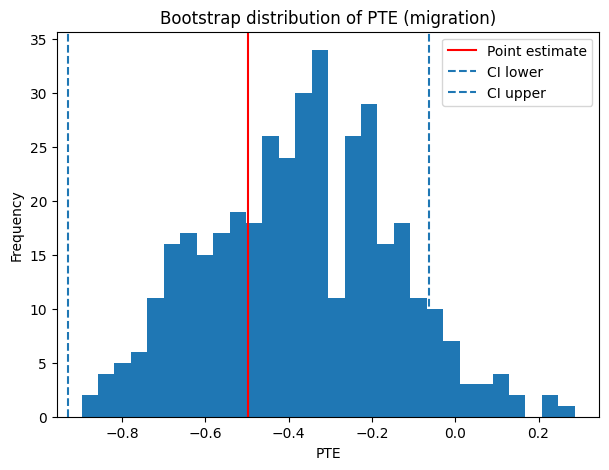

In [18]:
# ============================================================
# GRAFICO DISTRIBUCION BOOTSTRAP — MFLOW
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# histograma de replicaciones bootstrap
plt.hist(boot_m_valid["pte"], bins=30)

# estimador puntual
plt.axvline(pte_mflow, color="red", label="Point estimate")

# intervalos de confianza
plt.axvline(ci_low_m, linestyle="--", label="CI lower")
plt.axvline(ci_high_m, linestyle="--", label="CI upper")

plt.title("Bootstrap distribution of PTE (migration)")
plt.xlabel("PTE")
plt.ylabel("Frequency")

plt.legend()

plt.show()

---
## Sección 7 — Bootstrap por corredores (`vflow`)

Mismo procedimiento que la Sección 6, aplicado a `vflow`.

### Consideraciones específicas para `vflow`

- **Menor número de corredores** (G = 135 vs. 158 en `mflow`): la distribución bootstrap puede ser más variable.
- **Riesgo de replicaciones fallidas:** En algunas muestras bootstrap la submuestra de no-tratados puede carecer de variación en algún efecto fijo (un `cj_year` que aparece una sola vez y queda del lado tratado), lo que impide a `statsmodels` converger. Estas réplicas se registran como `NaN`.
- Se reporta explícitamente el número de réplicas válidas. Si la tasa de fallos es alta, el error estándar puede estar subestimado y conviene aumentar `BOOT_REPS`.

In [19]:
rng = np.random.default_rng(BOOT_SEED)

base_b2 = df.dropna(subset=["vflow", TREATMENT, "didcode_ij", "ci_year", "cj_year", "network"]).copy()
clusters2 = base_b2["didcode_ij"].dropna().unique()
G2 = len(clusters2)

boot_rows_v = []

print("Bootstrap vflow")
print("Número de corredores:", G2)
print("Replicaciones:", BOOT_REPS)

for r in range(BOOT_REPS):
    sampled2 = rng.choice(clusters2, size=G2, replace=True)

    pieces2 = []
    draw_id2 = 0

    for cid in sampled2:
        tmp2 = base_b2.loc[base_b2["didcode_ij"] == cid].copy()
        tmp2["_boot_draw"] = draw_id2
        tmp2["_boot_cluster"] = tmp2["didcode_ij"].astype(str) + "__" + str(draw_id2)
        pieces2.append(tmp2)
        draw_id2 += 1

    boot_df2 = pd.concat(pieces2, ignore_index=True)

    for col in ["ci_year", "cj_year", "_boot_cluster"]:
        boot_df2[col] = boot_df2[col].astype("category")

    boot_unt2 = boot_df2.loc[boot_df2[TREATMENT] == 0].copy()

    # diferencia mínima con mflow: limpiar categorías no usadas
    for col in ["ci_year", "cj_year", "_boot_cluster"]:
        boot_unt2[col] = boot_unt2[col].cat.remove_unused_categories()

    for col in ["ci_year", "cj_year", "_boot_cluster"]:
        boot_df2[col] = pd.Categorical(boot_df2[col], categories=boot_unt2[col].cat.categories)

    boot_formula2 = "vflow ~ network + C(ci_year) + C(cj_year) + C(_boot_cluster)"

    try:
        boot_mod2 = smf.glm(
            formula=boot_formula2,
            data=boot_unt2,
            family=sm.families.Poisson()
        )

        boot_res2 = boot_mod2.fit(method="newton", maxiter=200, disp=False)

        boot_df2["vflow_yhat0"] = boot_res2.predict(boot_df2)
        boot_df2["vflow_ites"] = boot_df2["vflow"] - boot_df2["vflow_yhat0"]

        boot_treat2 = boot_df2[TREATMENT] == 1

        boot_pte2 = (
            boot_df2.loc[boot_treat2, "vflow_ites"].sum()
            / boot_df2.loc[boot_treat2, "vflow_yhat0"].sum()
        )

        boot_rows_v.append({
            "rep": r + 1,
            "pte": boot_pte2,
            "beta_network": boot_res2.params["network"]
        })

    except Exception as e:
        continue

    if (r + 1) % 50 == 0:
        print("Rep:", r + 1)

boot_v = pd.DataFrame(boot_rows_v)

print("\nBootstrap terminado")
print("Replicaciones válidas:", len(boot_v))
print("Replicaciones fallidas:", BOOT_REPS - len(boot_v))

display(boot_v.head())



Bootstrap vflow
Número de corredores: 135
Replicaciones: 500


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Rep: 500

Bootstrap terminado
Replicaciones válidas: 490
Replicaciones fallidas: 10


C:\Users\natal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,rep,pte,beta_network
0,1,-0.941518,-0.783338
1,2,-0.400881,-0.001225
2,3,-0.682838,-0.370798
3,4,-0.633155,-0.403102
4,5,-0.303411,-0.634496


### 7B — Intervalos de confianza bootstrap (`vflow`)

Se calcula el SE bootstrap y los ICs de Wald al 95% para `vflow`. Notar que el número de réplicas válidas puede ser menor que `BOOT_REPS` si algunas muestras bootstrap no convergieron.

In [20]:
boot_valid = boot_v["pte"].dropna()

se = boot_valid.std(ddof=1)

ci_low = pte_vflow - 1.96 * se
ci_high = pte_vflow + 1.96 * se

print("Point estimate (PTE):", pte_vflow)
print("Bootstrap SE:", se)
print("CI95:", ci_low, ci_high)

print("\nBootstrap diagnostics")
print("Valid reps:", len(boot_valid))
print("Mean bootstrap PTE:", boot_valid.mean())
print("Median bootstrap PTE:", boot_valid.median())

Point estimate (PTE): -0.26724644705679307
Bootstrap SE: 0.3388927052147695
CI95: -0.9314761492777412 0.39698325516415517

Bootstrap diagnostics
Valid reps: 490
Mean bootstrap PTE: -0.4047506326300986
Median bootstrap PTE: -0.41814451746156417


In [21]:
boot_v_valid = boot_v.dropna(subset=["pte"]).copy()

se_v = boot_v_valid["pte"].std(ddof=1)
ci_low_v = pte_vflow - 1.96 * se_v
ci_high_v = pte_vflow + 1.96 * se_v

summary_boot_v = pd.DataFrame({
    "outcome": ["vflow"],
    "pte": [pte_vflow],
    "se_boot": [se_v],
    "ci95_low": [ci_low_v],
    "ci95_high": [ci_high_v],
    "boot_valid": [len(boot_v_valid)]
})

display(summary_boot_v)


,outcome,pte,se_boot,ci95_low,ci95_high,boot_valid
0,vflow,-0.267246,0.338893,-0.931476,0.396983,490


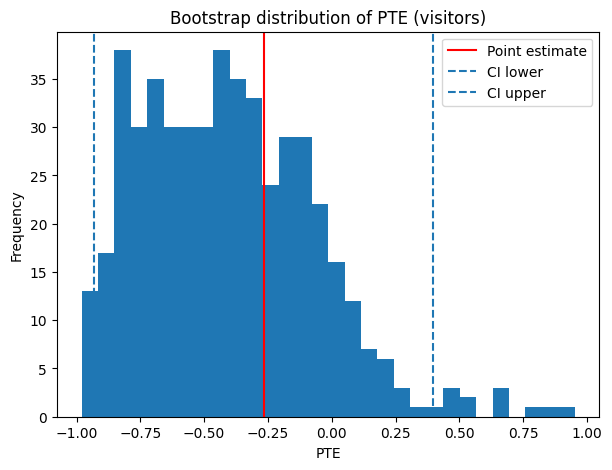

In [22]:
# ============================================================
# GRAFICO DISTRIBUCION BOOTSTRAP — MFLOW
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# histograma de replicaciones bootstrap
plt.hist(boot_v_valid["pte"], bins=30)

# estimador puntual
plt.axvline(pte_vflow, color="red", label="Point estimate")

# intervalos de confianza
plt.axvline(ci_low_v, linestyle="--", label="CI lower")
plt.axvline(ci_high_v, linestyle="--", label="CI upper")

plt.title("Bootstrap distribution of PTE (visitors)")
plt.xlabel("PTE")
plt.ylabel("Frequency")

plt.legend()

plt.show()

---
## Sección 8 — Tabla final y visualizaciones diagnósticas

Resultados finales del análisis: tabla comparativa de PTEs para ambos outcomes y serie de gráficos para interpretar los resultados e inspeccionar el ajuste del modelo.

In [23]:
final_table = pd.DataFrame({
    "outcome": ["migration", "visitor mobility"],
    "beta_network": [glm_res.params["network"], glm_res2.params["network"]],
    "pte": [pte_mflow, pte_vflow],
    "N": [len(work), len(work2)],
    "N_treated": [int(treat_mask.sum()), int(treat2_mask.sum())]
})

display(final_table)

,outcome,beta_network,pte,N,N_treated
0,migration,0.564179,-0.496780,4212,1021
1,visitor mobility,-0.191238,-0.267246,2873,900


In [24]:
# ============================================================
# TABLA FINAL 
# ============================================================

# ---------- mflow ----------
se_m = boot_m["pte"].std(ddof=1)
ci_low_m = pte_mflow - 1.96 * se_m
ci_high_m = pte_mflow + 1.96 * se_m

N_m = len(work)
N_treated_m = int((work[TREATMENT] == 1).sum())
origins_m = work["code_i"].nunique() if "code_i" in work.columns else np.nan
destinations_m = work["code_j"].nunique() if "code_j" in work.columns else np.nan
corridors_m = work["didcode_ij"].nunique()
periods_m = work["year"].nunique() if "year" in work.columns else np.nan

# ---------- vflow ----------
se_v = boot_v["pte"].std(ddof=1)
ci_low_v = pte_vflow - 1.96 * se_v
ci_high_v = pte_vflow + 1.96 * se_v

N_v = len(work2)
N_treated_v = int((work2[TREATMENT] == 1).sum())
origins_v = work2["code_i"].nunique() if "code_i" in work2.columns else np.nan
destinations_v = work2["code_j"].nunique() if "code_j" in work2.columns else np.nan
corridors_v = work2["didcode_ij"].nunique()
periods_v = work2["year"].nunique() if "year" in work2.columns else np.nan

# ---------- tabla ----------
final_table = pd.DataFrame({
    " ": [
        "average PTE",
        "SE",
        "CI 95%",
        "N",
        "N treated",
        "origins",
        "destinations",
        "corridors",
        "periods"
    ],
    "1 migration": [
        round(pte_mflow, 3),
        f"({se_m:.3f})",
        f"[{ci_low_m:.3f}, {ci_high_m:.3f}]",
        N_m,
        N_treated_m,
        origins_m,
        destinations_m,
        corridors_m,
        periods_m
    ],
    "2 visitor mobility": [
        round(pte_vflow, 3),
        f"({se_v:.3f})",
        f"[{ci_low_v:.3f}, {ci_high_v:.3f}]",
        N_v,
        N_treated_v,
        origins_v,
        destinations_v,
        corridors_v,
        periods_v
    ]
})

display(final_table)

,,1 migration,2 visitor mobility
0,average PTE,-0.497,-0.267
1,SE,(0.221),(0.339)
2,CI 95%,"[-0.931, -0.063]","[-0.931, 0.397]"
3,N,4212,2873
4,N treated,1021,960
5,origins,13,13
6,destinations,13,13
7,corridors,158,132
8,periods,27,27


### Visualizaciones diagnósticas

Los siguientes gráficos permiten inspeccionar la distribución de los efectos individuales del tratamiento, comparar flujos observados con el contrafáctico, y verificar la relación de red estimada.

#### Distribución de efectos individuales del tratamiento (`mflow`)

**Cómo leer el gráfico:**
- Cada barra representa cuántos corredores-año tuvieron un ITE (`ites = y - yhat0`) en ese rango.
- **Valores negativos** (izquierda del cero): en esos corredores-año el flujo observado fue **menor** que el contrafáctico — el FMR estuvo asociado a una reducción de flujos.
- **Valores positivos** (derecha del cero): el FMR estuvo asociado a un aumento.
- La línea punteada en cero es la referencia. Si la mayor parte de la masa está a la izquierda, el efecto agregado (PTE) es negativo.

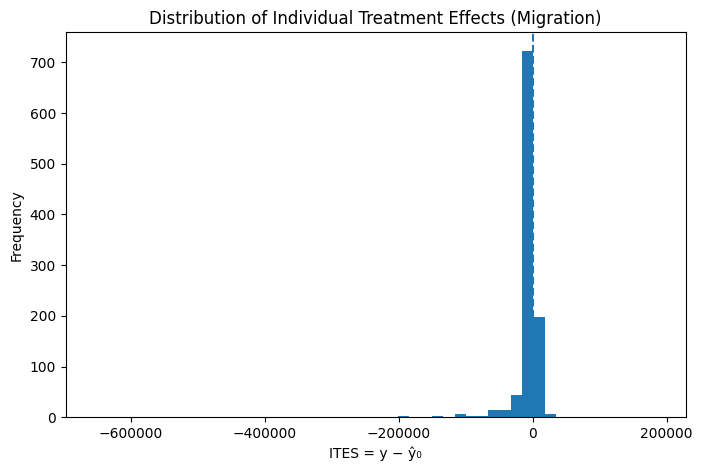

In [25]:
# ============================================================
# DISTRIBUCIÓN DE ITES — MFLOW
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(work.loc[treat_mask,"mflow_ites"], bins=50)

plt.axvline(0, linestyle="--")

plt.title("Distribution of Individual Treatment Effects (Migration)")
plt.xlabel("ITES = y − ŷ₀")
plt.ylabel("Frequency")

plt.show()

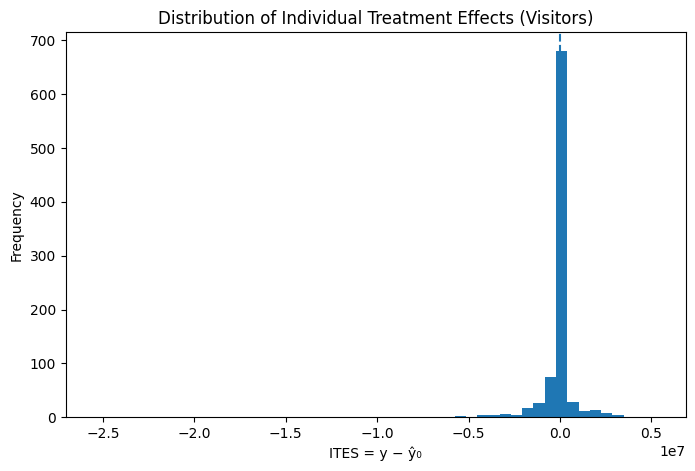

In [26]:
# ============================================================
# DISTRIBUCIÓN DE ITES — VFLOW
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(work2.loc[treat2_mask, "vflow_ites"], bins=50)

plt.axvline(0, linestyle="--")

plt.title("Distribution of Individual Treatment Effects (Visitors)")
plt.xlabel("ITES = y − ŷ₀")
plt.ylabel("Frequency")

plt.show()

#### Flujos observados vs. contrafáctico agregado (`mflow`)

**Cómo leer el gráfico:**
- La barra **"Observed"** es la suma total de flujos migratorios observados en los corredores tratados.
- La barra **"Counterfactual"** es `sum(yhat0)` sobre los mismos corredores: lo que el modelo predice que hubiera ocurrido sin FMR.
- La diferencia relativa entre ambas barras es el PTE: `(Obs − CF) / CF`. Si la barra observada es más baja que la contrafáctica, el FMR redujo los flujos agregados.

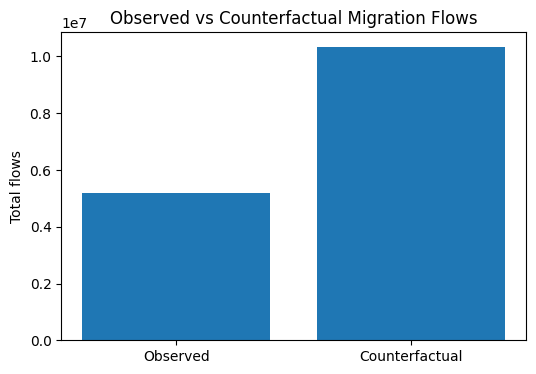

In [27]:
# ============================================================
# AGREGADO OBSERVED VS COUNTERFACTUAL
# ============================================================

obs_total = work.loc[treat_mask,"mflow"].sum()
cf_total  = work.loc[treat_mask,"mflow_yhat0"].sum()

labels = ["Observed","Counterfactual"]
values = [obs_total, cf_total]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Observed vs Counterfactual Migration Flows")
plt.ylabel("Total flows")

plt.show()

#### Relación entre `network` y flujos migratorios

**Cómo leer el gráfico:**
- Cada punto es una observación corredor-año.
- El eje X es `network = log(mstock_{t-1})`: mayor valor indica una red migratoria más establecida.
- El eje Y es el flujo migratorio observado (`mflow`).
- Una nube con pendiente positiva confirma el **efecto de red**: destinos con mayor comunidad previa atraen más migrantes. El coeficiente `beta_network` captura esta pendiente en escala log-log.
- La dispersión refleja variación no explicada por la red (absorbida por los efectos fijos en la estimación).

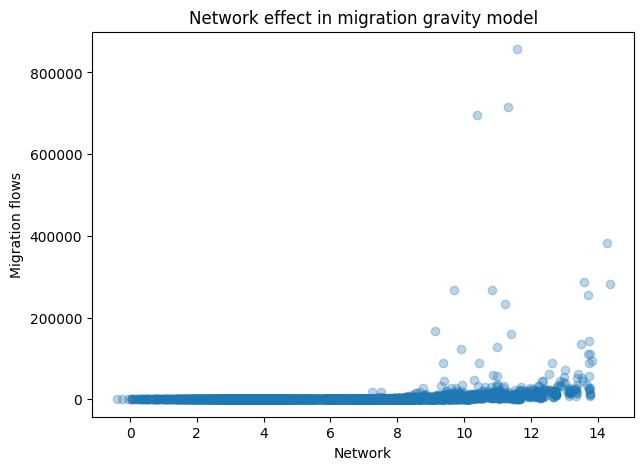

In [28]:
# ============================================================
# NETWORK VS FLOWS
# ============================================================

plt.figure(figsize=(7,5))

plt.scatter(work["network"], work["mflow"], alpha=0.3)

plt.xlabel("Network")
plt.ylabel("Migration flows")

plt.title("Network effect in migration gravity model")

plt.show()

#### Comparación de PTEs: migración vs. movilidad de visitantes

**Cómo leer el gráfico:**
- Cada barra muestra el PTE puntual para cada outcome.
- La línea punteada en cero es la referencia de "sin efecto".
- **Ambos PTEs negativos** indicarían que el FMR está asociado a menores flujos de los esperados en ambas dimensiones. Esto puede interpretarse como sustitución de flujos irregulares por regulares (que no se capturan en los datos), u otros efectos de composición.
- La **diferencia en magnitud** entre `mflow` y `vflow` refleja heterogeneidad en la respuesta: los acuerdos pueden afectar de modo distinto la migración permanente y la movilidad temporal de visitantes.

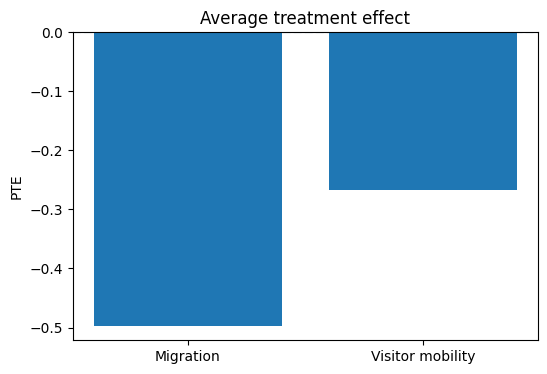

In [29]:
# ============================================================
# COMPARISON OF PTE
# ============================================================

outcomes = ["Migration","Visitor mobility"]
pte_vals = [pte_mflow, pte_vflow]

plt.figure(figsize=(6,4))
plt.bar(outcomes, pte_vals)

plt.axhline(0, linestyle="--")

plt.ylabel("PTE")
plt.title("Average treatment effect")

plt.show()